# Notebook 04 - Hybrid SAM-U-Net

This notebook trains a Hybrid SAM-U-Net for flood segmentation using the outputs from Notebook 03.

Inputs from Notebook 03:

- RGB images: `(3, 128, 128)` using B04, B03, B02
- Flood masks: `(128, 128)`
- SAM ViT-B embeddings: `(256, 64, 64)`

Core requirements handled here:

- Use RGB-only STURM optical imagery.
- Load precomputed SAM embeddings from Notebook 03.
- Fuse U-Net encoder features with SAM image embeddings before the bottleneck.
- Print encoder feature shape, SAM feature shape, and resized SAM feature shape.
- Train with train/validation tracking.
- Save checkpoints and training history.
- Generate loss and accuracy curves.
- Provide metric functions for Accuracy, Precision, Recall, F1, IoU, mIoU, and Dice.

In [3]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("Libraries loaded")

Libraries loaded


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("CUDA device:", torch.cuda.get_device_name(0))

Device: cuda
CUDA device: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [5]:
PROJECT_ROOT = Path(r"D:\Research\hybrid_sam\FusionSAM-Flood-Mapping")
RGB_ROOT = PROJECT_ROOT / "dataset" / "processed" / "STRUM_RGB_TEMP"
SAM_EMBEDDING_ROOT = PROJECT_ROOT / "dataset" / "sam_embeddings" / "strum_rgb_vit_b"
NOTEBOOK_03_SUMMARY = PROJECT_ROOT / "results" / "notebook_03_sam_features" / "notebook_03_summary.json"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "hybrid_sam_unet"
RESULTS_DIR = PROJECT_ROOT / "results" / "notebook_04_hybrid_sam_unet"
CURVE_DIR = RESULTS_DIR / "curves"
PREDICTION_DIR = RESULTS_DIR / "sample_predictions"

for path in [CHECKPOINT_DIR, RESULTS_DIR, CURVE_DIR, PREDICTION_DIR]:
    path.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 4
NUM_WORKERS = 0  # Windows/Jupyter-friendly
PIN_MEMORY = DEVICE == "cuda"
LR = 1e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 60  
THRESHOLD = 0.5
RESUME_TRAINING = True
USE_AMP = DEVICE == "cuda"

BEST_CHECKPOINT = CHECKPOINT_DIR / "best_hybrid_sam_unet.pth"
LAST_CHECKPOINT = CHECKPOINT_DIR / "last_hybrid_sam_unet.pth"
HISTORY_CSV = RESULTS_DIR / "hybrid_sam_unet_history.csv"

print("RGB root exists:", RGB_ROOT.exists())
print("SAM embedding root exists:", SAM_EMBEDDING_ROOT.exists())
print("Notebook 03 summary exists:", NOTEBOOK_03_SUMMARY.exists())

RGB root exists: True
SAM embedding root exists: True
Notebook 03 summary exists: True


In [6]:
if NOTEBOOK_03_SUMMARY.exists():
    with open(NOTEBOOK_03_SUMMARY, "r", encoding="utf-8") as f:
        nb03_summary = json.load(f)
    print(json.dumps({
        "split_policy": nb03_summary.get("split_policy"),
        "rgb_input_shape_chw": nb03_summary.get("rgb_input_shape_chw"),
        "sam_embedding_shape_chw": nb03_summary.get("sam_embedding_shape_chw"),
        "split_summary": nb03_summary.get("split_summary"),
    }, indent=2))
else:
    nb03_summary = {}
    print("Notebook 03 summary not found. Continuing with path-based validation.")

{
  "split_policy": "deterministic 80/10/10 temporary split, random_state=42",
  "rgb_input_shape_chw": [
    3,
    128,
    128
  ],
  "sam_embedding_shape_chw": [
    256,
    64,
    64
  ],
  "split_summary": {
    "train": 2140,
    "val": 267,
    "test": 268,
    "total": 2675,
    "ratios": {
      "train": 0.8,
      "val": 0.09981308411214954,
      "test": 0.10018691588785046
    }
  }
}


## Dataset Validation

Images, masks, and SAM embeddings are matched by the same `.npy` filename. This avoids depending on notebook execution order outside the files created by Notebook 03.

In [8]:
def split_paths(split: str):
    return {
        "images": RGB_ROOT / split / "images",
        "masks": RGB_ROOT / split / "masks",
        "embeddings": SAM_EMBEDDING_ROOT / split,
    }


def validate_split(split: str) -> dict:
    paths = split_paths(split)
    image_files = {p.name: p for p in paths["images"].glob("*.npy")}
    mask_files = {p.name: p for p in paths["masks"].glob("*.npy")}
    embedding_files = {p.name: p for p in paths["embeddings"].glob("*.npy")}
    common = sorted(set(image_files) & set(mask_files) & set(embedding_files))

    missing_masks = sorted(set(image_files) - set(mask_files))
    missing_embeddings = sorted(set(image_files) - set(embedding_files))

    summary = {
        "split": split,
        "image_count": len(image_files),
        "mask_count": len(mask_files),
        "embedding_count": len(embedding_files),
        "matched_count": len(common),
        "missing_masks": len(missing_masks),
        "missing_embeddings": len(missing_embeddings),
    }
    return summary

validation_summary = {split: validate_split(split) for split in ["train", "val", "test"]}
print(json.dumps(validation_summary, indent=2))

with open(RESULTS_DIR / "input_validation_summary.json", "w", encoding="utf-8") as f:
    json.dump(validation_summary, f, indent=2)

for split, summary in validation_summary.items():
    assert summary["matched_count"] > 0, f"No matched data found for {split}"
    assert summary["matched_count"] == summary["image_count"], f"Missing masks or embeddings in {split}"

{
  "train": {
    "split": "train",
    "image_count": 2140,
    "mask_count": 2140,
    "embedding_count": 2140,
    "matched_count": 2140,
    "missing_masks": 0,
    "missing_embeddings": 0
  },
  "val": {
    "split": "val",
    "image_count": 267,
    "mask_count": 267,
    "embedding_count": 267,
    "matched_count": 267,
    "missing_masks": 0,
    "missing_embeddings": 0
  },
  "test": {
    "split": "test",
    "image_count": 268,
    "mask_count": 268,
    "embedding_count": 268,
    "matched_count": 268,
    "missing_masks": 0,
    "missing_embeddings": 0
  }
}


In [9]:
class SAMFloodDataset(Dataset):
    def __init__(self, split: str):
        self.split = split
        paths = split_paths(split)
        self.image_dir = paths["images"]
        self.mask_dir = paths["masks"]
        self.embedding_dir = paths["embeddings"]

        image_names = {p.name for p in self.image_dir.glob("*.npy")}
        mask_names = {p.name for p in self.mask_dir.glob("*.npy")}
        embedding_names = {p.name for p in self.embedding_dir.glob("*.npy")}
        self.files = sorted(image_names & mask_names & embedding_names)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]
        image = np.load(self.image_dir / name).astype(np.float32)
        mask = np.load(self.mask_dir / name).astype(np.float32)
        sam_feature = np.load(self.embedding_dir / name).astype(np.float32)

        image = np.nan_to_num(image, nan=0.0, posinf=1.0, neginf=0.0)
        image = np.clip(image, 0.0, 1.0)
        mask = (np.nan_to_num(mask) > 0).astype(np.float32)
        sam_feature = np.nan_to_num(sam_feature, nan=0.0, posinf=0.0, neginf=0.0)

        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask).unsqueeze(0)
        sam_feature = torch.from_numpy(sam_feature)
        return image, mask, sam_feature, name

train_dataset = SAMFloodDataset("train")
val_dataset = SAMFloodDataset("val")
test_dataset = SAMFloodDataset("test")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Train/Val/Test:", len(train_dataset), len(val_dataset), len(test_dataset))

Train/Val/Test: 2140 267 268


In [10]:
image, mask, sam_feature, name = train_dataset[0]
print("Sample file:", name)
print("RGB image shape:", tuple(image.shape))
print("Mask shape:", tuple(mask.shape))
print("SAM feature shape:", tuple(sam_feature.shape))
print("Image range:", float(image.min()), float(image.max()))
print("Mask values:", torch.unique(mask))

Sample file: EMSR279_03ALFARO_17_16_1_1.npy
RGB image shape: (3, 128, 128)
Mask shape: (1, 128, 128)
SAM feature shape: (256, 64, 64)
Image range: 0.0 1.0
Mask values: tensor([0., 1.])


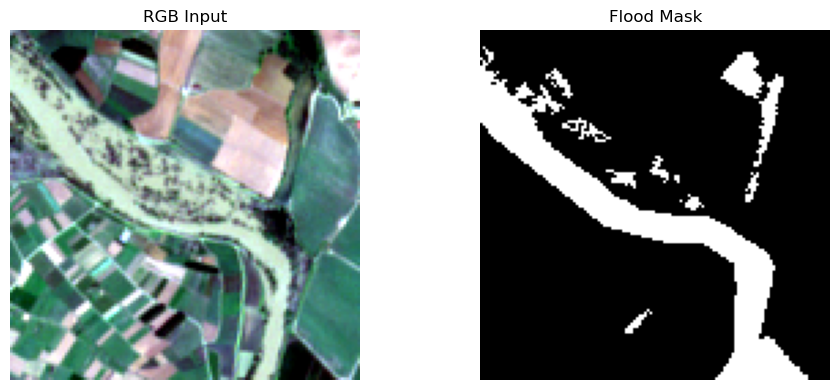

In [11]:
rgb = image.permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("RGB Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze(0).numpy(), cmap="gray")
plt.title("Flood Mask")
plt.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_sample_rgb_mask.png", dpi=200, bbox_inches="tight")
plt.show()

## Model

The architecture follows the previous implementation's small two-level U-Net so comparison stays fair, but changes the input from 9 channels to 3 channels.

Fusion location:

- Encoder `p2`: output after the second pooling operation.
- SAM feature: precomputed ViT-B image embedding.
- Resize strategy: bilinear interpolation with `align_corners=False` from SAM spatial size to encoder `p2` spatial size.
- Fusion: channel-wise concatenation before the bottleneck.

For the expected data shapes:

- Encoder `p2`: `(B, 128, 32, 32)`
- Raw SAM: `(B, 256, 64, 64)`
- Resized SAM: `(B, 256, 32, 32)`
- Fusion tensor: `(B, 384, 32, 32)`

In [13]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class HybridSAMUNet(nn.Module):
    def __init__(self, in_channels: int = 3, sam_channels: int = 256):
        super().__init__()
        self.e1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.e2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128 + sam_channels, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d1 = DoubleConv(128 + 128, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.d2 = DoubleConv(64 + 64, 64)
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x, sam_feature, return_shapes: bool = False):
        e1 = self.e1(x)
        p1 = self.pool1(e1)
        e2 = self.e2(p1)
        p2 = self.pool2(e2)

        raw_sam_shape = tuple(sam_feature.shape)
        sam_resized = F.interpolate(
            sam_feature,
            size=p2.shape[2:],
            mode="bilinear",
            align_corners=False,
        )

        fusion = torch.cat([p2, sam_resized], dim=1)
        b = self.bottleneck(fusion)

        u1 = self.up1(b)
        u1 = torch.cat([u1, e2], dim=1)
        d1 = self.d1(u1)

        u2 = self.up2(d1)
        u2 = torch.cat([u2, e1], dim=1)
        d2 = self.d2(u2)
        logits = self.out(d2)

        if return_shapes:
            return logits, {
                "encoder_p2_shape": tuple(p2.shape),
                "sam_feature_shape": raw_sam_shape,
                "resized_sam_feature_shape": tuple(sam_resized.shape),
                "fusion_tensor_shape": tuple(fusion.shape),
                "output_shape": tuple(logits.shape),
                "resize_strategy": "torch.nn.functional.interpolate(mode='bilinear', align_corners=False)",
            }
        return logits

model = HybridSAMUNet(in_channels=3, sam_channels=256).to(DEVICE)
print(model.__class__.__name__)
print("Parameters:", sum(p.numel() for p in model.parameters()))

HybridSAMUNet
Parameters: 2453953


In [14]:
# Required feature-map size analysis.
model.eval()
batch = next(iter(train_loader))
batch_images, batch_masks, batch_sam_features, batch_names = batch
batch_images = batch_images.to(DEVICE)
batch_sam_features = batch_sam_features.to(DEVICE)

with torch.no_grad():
    _, shape_report = model(batch_images, batch_sam_features, return_shapes=True)

print("Feature-map fusion shape report")
for key, value in shape_report.items():
    print(f"{key}: {value}")

with open(RESULTS_DIR / "feature_fusion_shape_report.json", "w", encoding="utf-8") as f:
    json.dump(shape_report, f, indent=2)

Feature-map fusion shape report
encoder_p2_shape: (4, 128, 32, 32)
sam_feature_shape: (4, 256, 64, 64)
resized_sam_feature_shape: (4, 256, 32, 32)
fusion_tensor_shape: (4, 384, 32, 32)
output_shape: (4, 1, 128, 128)
resize_strategy: torch.nn.functional.interpolate(mode='bilinear', align_corners=False)


## Loss and Metrics

Training uses BCEWithLogitsLoss plus Dice loss, matching the previous implementation's class-imbalance handling.

Accuracy is tracked during training/validation for the required curves. The full metric function below is also used for validation/test summaries and later evaluation compatibility.

In [16]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.contiguous().view(probs.shape[0], -1)
        targets = targets.contiguous().view(targets.shape[0], -1)
        intersection = (probs * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (probs.sum(dim=1) + targets.sum(dim=1) + self.smooth)
        return 1.0 - dice.mean()

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)

In [17]:
def confusion_counts(logits, targets, threshold: float = THRESHOLD):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).bool()
    targets = targets.bool()

    tp = (preds & targets).sum().float()
    tn = ((~preds) & (~targets)).sum().float()
    fp = (preds & (~targets)).sum().float()
    fn = ((~preds) & targets).sum().float()
    return tp, tn, fp, fn


def metrics_from_counts(tp, tn, fp, fn, eps: float = 1e-7):
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou_flood = tp / (tp + fp + fn + eps)
    iou_background = tn / (tn + fp + fn + eps)
    miou = (iou_flood + iou_background) / 2
    dice = 2 * tp / (2 * tp + fp + fn + eps)
    return {
        "accuracy": accuracy.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "f1": f1.item(),
        "iou": iou_flood.item(),
        "miou": miou.item(),
        "dice": dice.item(),
    }


def evaluate_metrics(model, loader, threshold: float = THRESHOLD):
    model.eval()
    total_loss = 0.0
    tp = torch.tensor(0.0, device=DEVICE)
    tn = torch.tensor(0.0, device=DEVICE)
    fp = torch.tensor(0.0, device=DEVICE)
    fn = torch.tensor(0.0, device=DEVICE)

    with torch.no_grad():
        for images, masks, sam_features, _ in loader:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            sam_features = sam_features.to(DEVICE, non_blocking=True)
            logits = model(images, sam_features)
            loss = combined_loss(logits, masks)
            total_loss += loss.item()
            b_tp, b_tn, b_fp, b_fn = confusion_counts(logits, masks, threshold)
            tp += b_tp
            tn += b_tn
            fp += b_fp
            fn += b_fn

    metrics = metrics_from_counts(tp, tn, fp, fn)
    metrics["loss"] = total_loss / max(len(loader), 1)
    return metrics

In [18]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

start_epoch = 0
best_val_loss = math.inf
history = []

if RESUME_TRAINING and LAST_CHECKPOINT.exists():
    checkpoint = torch.load(LAST_CHECKPOINT, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    if "scaler_state_dict" in checkpoint and USE_AMP:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
    start_epoch = int(checkpoint.get("epoch", 0)) + 1
    best_val_loss = float(checkpoint.get("best_val_loss", math.inf))
    history = checkpoint.get("history", [])
    print(f"Resumed from epoch {start_epoch}; best val loss = {best_val_loss:.6f}")
else:
    print("Starting fresh training")

Starting fresh training


In [19]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    tp = torch.tensor(0.0, device=DEVICE)
    tn = torch.tensor(0.0, device=DEVICE)
    fp = torch.tensor(0.0, device=DEVICE)
    fn = torch.tensor(0.0, device=DEVICE)

    for images, masks, sam_features, _ in tqdm(loader, desc="train", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        sam_features = sam_features.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images, sam_features)
            loss = combined_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        b_tp, b_tn, b_fp, b_fn = confusion_counts(logits.detach(), masks)
        tp += b_tp
        tn += b_tn
        fp += b_fp
        fn += b_fn

    metrics = metrics_from_counts(tp, tn, fp, fn)
    metrics["loss"] = total_loss / max(len(loader), 1)
    return metrics


def save_checkpoint(path: Path, epoch: int, best_val_loss: float):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if USE_AMP else None,
        "best_val_loss": best_val_loss,
        "history": history,
        "config": {
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "epochs": EPOCHS,
            "threshold": THRESHOLD,
            "rgb_root": str(RGB_ROOT),
            "sam_embedding_root": str(SAM_EMBEDDING_ROOT),
        },
        "shape_report": shape_report,
    }, path)

In [20]:
for epoch in range(start_epoch, EPOCHS):
    epoch_start = time.time()
    train_metrics = train_one_epoch(model, train_loader)
    val_metrics = evaluate_metrics(model, val_loader, THRESHOLD)
    scheduler.step(val_metrics["loss"])

    row = {
        "epoch": epoch + 1,
        "lr": optimizer.param_groups[0]["lr"],
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "val_precision": val_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "val_recall": val_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "val_f1": val_metrics["f1"],
        "train_iou": train_metrics["iou"],
        "val_iou": val_metrics["iou"],
        "train_miou": train_metrics["miou"],
        "val_miou": val_metrics["miou"],
        "train_dice": train_metrics["dice"],
        "val_dice": val_metrics["dice"],
        "seconds": time.time() - epoch_start,
    }
    history.append(row)

    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        save_checkpoint(BEST_CHECKPOINT, epoch, best_val_loss)
        best_marker = " saved best"
    else:
        best_marker = ""

    save_checkpoint(LAST_CHECKPOINT, epoch, best_val_loss)

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"train loss {train_metrics['loss']:.4f}, val loss {val_metrics['loss']:.4f} | "
        f"train acc {train_metrics['accuracy']:.4f}, val acc {val_metrics['accuracy']:.4f} | "
        f"val Dice {val_metrics['dice']:.4f}, val IoU {val_metrics['iou']:.4f} | "
        f"lr {optimizer.param_groups[0]['lr']:.2e}{best_marker}"
    )

print("Training complete")
print("Best validation loss:", best_val_loss)
print("History saved to:", HISTORY_CSV)

Epoch 001/60 | train loss 1.1909, val loss 1.1146 | train acc 0.7568, val acc 0.8022 | val Dice 0.6196, val IoU 0.4489 | lr 1.00e-04 saved best


Epoch 002/60 | train loss 1.1194, val loss 1.0737 | train acc 0.7902, val acc 0.7993 | val Dice 0.6598, val IoU 0.4923 | lr 1.00e-04 saved best


Epoch 003/60 | train loss 1.0862, val loss 1.0562 | train acc 0.8057, val acc 0.7985 | val Dice 0.6424, val IoU 0.4732 | lr 1.00e-04 saved best


Epoch 004/60 | train loss 1.0629, val loss 1.0137 | train acc 0.8143, val acc 0.8187 | val Dice 0.6817, val IoU 0.5171 | lr 1.00e-04 saved best


Epoch 005/60 | train loss 1.0266, val loss 1.0015 | train acc 0.8258, val acc 0.8281 | val Dice 0.6986, val IoU 0.5368 | lr 1.00e-04 saved best


...

Epoch 056/60 | train loss 0.5122, val loss 0.8578 | train acc 0.9316, val acc 0.8846 | val Dice 0.7750, val IoU 0.6327 | lr 3.13e-06


Epoch 057/60 | train loss 0.5127, val loss 0.8659 | train acc 0.9314, val acc 0.8852 | val Dice 0.7742, val IoU 0.6316 | lr 3.13e-06


Epoch 058/60 | train loss 0.5132, val loss 0.8677 | train acc 0.9318, val acc 0.8844 | val Dice 0.7755, val IoU 0.6333 | lr 3.13e-06


Epoch 059/60 | train loss 0.5084, val loss 0.8769 | train acc 0.9324, val acc 0.8850 | val Dice 0.7758, val IoU 0.6337 | lr 3.13e-06


Epoch 060/60 | train loss 0.5083, val loss 0.8732 | train acc 0.9323, val acc 0.8851 | val Dice 0.7748, val IoU 0.6323 | lr 3.13e-06
Training complete
Best validation loss: 0.8230089020373216
History saved to: D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\results\notebook_04_hybrid_sam_unet\hybrid_sam_unet_history.csv


## Training Curves

,epoch,lr,train_loss,val_loss,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1,train_iou,val_iou,train_miou,val_miou,train_dice,val_dice,seconds
55,56,0.000003,0.512191,0.857790,0.931560,0.884614,0.889047,0.803999,0.863346,0.748044,0.876008,0.775013,0.779372,0.632670,0.844555,0.744332,0.876008,0.775013,93.705267
56,57,0.000003,0.512693,0.865897,0.931386,0.885240,0.890148,0.811016,0.861267,0.740620,0.875469,0.774221,0.778519,0.631615,0.844048,0.744372,0.875469,0.774221,92.328642
57,58,0.000003,0.513170,0.867697,0.931752,0.884391,0.890876,0.801022,0.861855,0.751528,0.876125,0.775486,0.779558,0.633301,0.844799,0.744426,0.876126,0.775486,91.650466
58,59,0.000003,0.508373,0.876891,0.932372,0.884951,0.891280,0.804318,0.863877,0.749233,0.877365,0.775799,0.781523,0.633719,0.846157,0.745039,0.877365,0.775799,91.523444
59,60,0.000003,0.508262,0.873231,0.932350,0.885149,0.890234,0.808771,0.865086,0.743494,0.877480,0.774760,0.781705,0.632333,0.846214,0.744606,0.877480,0.774760,91.430062


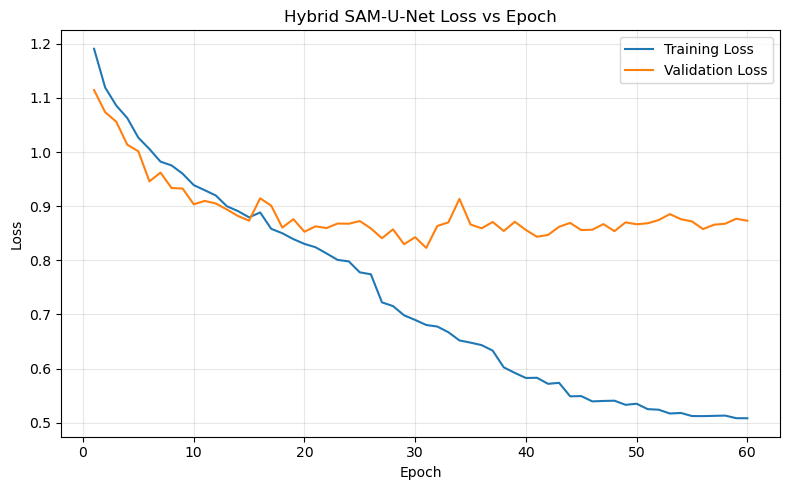

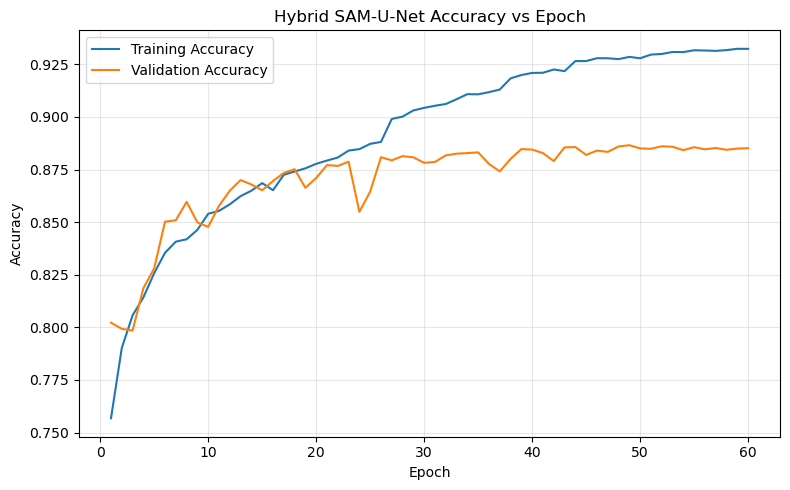

In [22]:
history_df = pd.read_csv(HISTORY_CSV)
display(history_df.tail())

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Training Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Hybrid SAM-U-Net Loss vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CURVE_DIR / "loss_vs_epoch.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Training Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Hybrid SAM-U-Net Accuracy vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CURVE_DIR / "accuracy_vs_epoch.png", dpi=200, bbox_inches="tight")
plt.show()

## Test Metrics for Hybrid SAM-U-Net

The final model comparison with Baseline U-Net should be done in Notebook 05 once the RGB baseline is available from Notebook 02. This cell still computes Hybrid SAM-U-Net test metrics now, using the same metric names required for the final report.

In [24]:
if BEST_CHECKPOINT.exists():
    checkpoint = torch.load(BEST_CHECKPOINT, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Loaded best checkpoint:", BEST_CHECKPOINT)
else:
    print("Best checkpoint not found; using current model weights")

test_metrics = evaluate_metrics(model, test_loader, THRESHOLD)
print("Hybrid SAM-U-Net Test Metrics")
for key in ["accuracy", "precision", "recall", "f1", "iou", "miou", "dice", "loss"]:
    print(f"{key}: {test_metrics[key]:.6f}")

with open(RESULTS_DIR / "hybrid_sam_unet_test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)

Loaded best checkpoint: D:\Research\hybrid_sam\FusionSAM-Flood-Mapping\checkpoints\hybrid_sam_unet\best_hybrid_sam_unet.pth
Hybrid SAM-U-Net Test Metrics
accuracy: 0.886526
precision: 0.761444
recall: 0.800537
f1: 0.780501
iou: 0.640018
miou: 0.748933
dice: 0.780501
loss: 0.811152


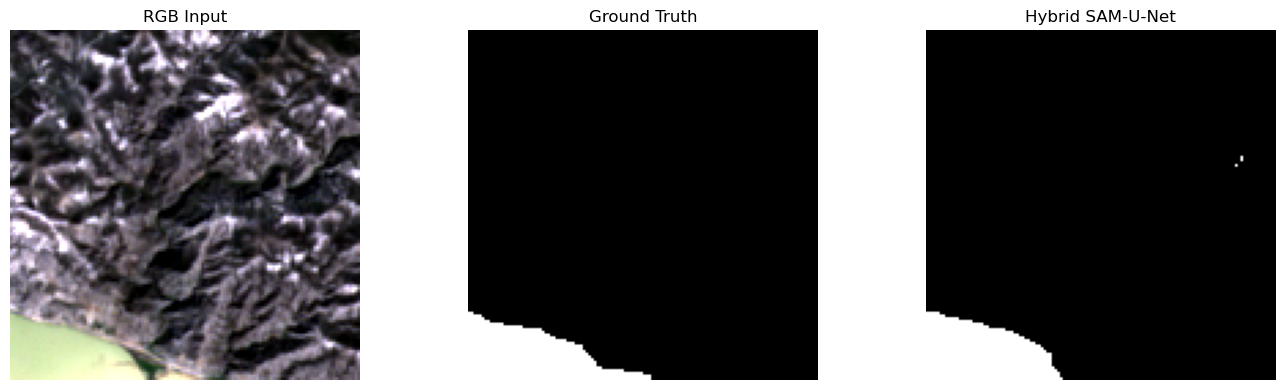

Sample file: EMSR279_05ZARAGOZA_02_04_1_2.npy


In [25]:
# Save a qualitative prediction sample.
model.eval()
images, masks, sam_features, names = next(iter(test_loader))
images = images.to(DEVICE)
sam_features = sam_features.to(DEVICE)

with torch.no_grad():
    logits = model(images, sam_features)
    probs = torch.sigmoid(logits)
    preds = (probs >= THRESHOLD).float().cpu()

idx = 0
rgb = images[idx].cpu().permute(1, 2, 0).numpy()
gt = masks[idx, 0].numpy()
pred = preds[idx, 0].numpy()

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title("RGB Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("Hybrid SAM-U-Net")
plt.axis("off")

plt.tight_layout()
plt.savefig(PREDICTION_DIR / "hybrid_sam_unet_prediction_sample.png", dpi=200, bbox_inches="tight")
plt.show()

print("Sample file:", names[idx])

## Outputs for Later Evaluation

Notebook 05 can use these files:

- Best checkpoint: `checkpoints/hybrid_sam_unet/best_hybrid_sam_unet.pth`
- Last checkpoint: `checkpoints/hybrid_sam_unet/last_hybrid_sam_unet.pth`
- Training history: `results/notebook_04_hybrid_sam_unet/hybrid_sam_unet_history.csv`
- Fusion shape report: `results/notebook_04_hybrid_sam_unet/feature_fusion_shape_report.json`
- Test metrics: `results/notebook_04_hybrid_sam_unet/hybrid_sam_unet_test_metrics.json`
- Curves: `results/notebook_04_hybrid_sam_unet/curves/`

